In [100]:
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import pandas as pd
import seaborn as sns


In [101]:
def compute_ensemble_stddev(
    df_preds,
    scorer_name='standard_scorer',
    keypoints_list=None,
):
    """
    Parameters
    ----------
    df_preds : List[pd.DataFrame]
        model predictions
    keypoints_list : List[str]
        keypoints to include in the analysis

    Returns
    -------
    np.ndarray
        shape (n_frames, n_keypoints)
    """
    # Initial check for NaNs in df_preds
    for i, df in enumerate(df_preds):
        if df.isna().any().any():
            print(f"Warning: NaN values detected in initial DataFrame {i}.")
            nan_indices = df[df.isna().any(axis=1)].index
            nan_columns = df.columns[df.isna().any()]
            print(f"NaN values found at indices: {nan_indices} in columns: {nan_columns}")

    preds = []
    for i, df in enumerate(df_preds):
        # Standardize the 'scorer' level
        df = standardize_scorer_level(df, scorer_name)

        # Remove likelihood columns
        cols_to_keep = [
            col for col in df.columns
            if not col[2].endswith('likelihood') and 'Unnamed' not in col[2] and (keypoints_list is None or col[1] in keypoints_list)]
        df = df[cols_to_keep]

        print(f"DataFrame {i} kept columns:", df.columns)

        # Check for NaNs in the DataFrame
        if df.isna().any().any():
            print(f"Warning: NaN values detected in DataFrame {i} after filtering.")
            nan_indices = df[df.isna().any(axis=1)].index
            nan_columns = df.columns[df.isna().any()]
            print(f"NaN values found at indices: {nan_indices} in columns: {nan_columns}")

        # Reshape the DataFrame to the appropriate shape
        try:
            arr = df.to_numpy().reshape(df.shape[0], -1, 2)
        except ValueError as e:
            print(f"Reshape error: {e}")
            print(f"DataFrame shape: {df.shape}")
            print(f"Array shape after reshape attempt: {df.to_numpy().shape}")
            raise

        preds.append(arr[..., None])

    preds = np.concatenate(preds, axis=3)

    # Check for NaNs in preds
    if np.isnan(preds).any():
        print("Warning: NaN values detected in preds array.")
        nan_indices = np.argwhere(np.isnan(preds))
        print(f"NaN values found at indices: {nan_indices}")
    else:
        print("No NaN values detected in preds array.")

    stddevs = np.std(preds, axis=-1).mean(axis=-1)
    print(f"Stddevs: {stddevs}")
    return stddevs


def standardize_scorer_level(df, new_scorer='standard_scorer'):
    """
    Standardizes the 'scorer' level in the MultiIndex to a common name.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to standardize.
    new_scorer : str
        The new name for the 'scorer' level.

    Returns
    -------
    pd.DataFrame
        The DataFrame with the standardized 'scorer' level.
    """
    df.columns = pd.MultiIndex.from_tuples(
        [(new_scorer, bodypart, coord) for scorer, bodypart, coord in df.columns],
        names=df.columns.names
    )
    return df


def compute_percentiles(arr, std_vals, percentiles):
    num_pts = arr[0]
    vals = []
    prctiles = []
    for p in percentiles:
        v = num_pts * p / 100
        idx = np.argmin(np.abs(arr - v))
        # maybe we don't have enough data
        if idx == len(arr) - 1:
            p_ = arr[idx] / num_pts * 100
        else:
            p_ = p
        vals.append(std_vals[idx])
        prctiles.append(np.round(p_, 2))
    return vals, prctiles


In [102]:
# ground_truth_csv = '/media/mattw/behavior/pose-estimation-data-final/ibl-paw_256x320/CollectedData_new.csv'

data_to_plot = {
    # 'v0.0.0': 'fuse_outputs/chickadee/single_0/image_preds/CollectedData_merged.csv/predictions.csv',
    # 'v0.1.0': 'fuse_outputs/chickadee/single_1/image_preds/CollectedData_merged.csv/predictions.csv',
    # 'v0.2.0': 'fuse_outputs/chickadee/single_2/image_preds/CollectedData_merged.csv/predictions.csv',
    'v0.0.1': 'fuse_outputs/chickadee/single_0/image_preds/CollectedData_merged_new.csv/predictions.csv',
    'v0.1.1': 'fuse_outputs/chickadee/single_1/image_preds/CollectedData_merged_new.csv/predictions.csv',
    'v0.2.1': 'fuse_outputs/chickadee/single_2/image_preds/CollectedData_merged_new.csv/predictions.csv',
    # 'v1.0.0': 'fuse_outputs/chickadee/pose_0/image_preds/cropped_CollectedData_merged.csv/remapped_predictions.csv',
    # 'v1.1.0': 'fuse_outputs/chickadee/pose_1/image_preds/cropped_CollectedData_merged.csv/remapped_predictions.csv',
    # 'v1.2.0': 'fuse_outputs/chickadee/pose_2/image_preds/cropped_CollectedData_merged.csv/remapped_predictions.csv',
    'v1.0.1': 'fuse_outputs/chickadee/pose_0/image_preds/cropped_CollectedData_merged_new.csv/remapped_predictions.csv',
    'v1.1.1': 'fuse_outputs/chickadee/pose_1/image_preds/cropped_CollectedData_merged_new.csv/remapped_predictions.csv',
    'v1.2.1': 'fuse_outputs/chickadee/pose_2/image_preds/cropped_CollectedData_merged_new.csv/remapped_predictions.csv',
}


In [103]:
# define predictions so we can compute ensemble variance
pred_csv_list = []
# define model names
model_names_list = []
# reformat
for key, val in data_to_plot.items():
    model_names_list.append(key)
    pred_csv_list.append(Path(val))

error_csv_list = []
for p in pred_csv_list:
    p = p.with_stem(p.stem.replace("remapped_", "") + "_pixel_error")
    error_csv_list.append(p)

# load data
df_pred_list = []
df_error_list = []
for pred_csv, error_csv in zip(pred_csv_list, error_csv_list):
#     df_pred_list.append(pd.read_csv(pred_csv, header=[0, 1, 2], index_col=0).drop(columns=['set']))
#     df_error_list.append(pd.read_csv(error_csv, header=[0], index_col=0).drop(columns=['set']))
    preds_df = pd.read_csv(pred_csv, header=[0, 1, 2], index_col=0).sort_index()
    #cols_to_keep = [col for col in preds_df.columns if col[1] == 'topBeak']
    #preds_df = preds_df[cols_to_keep]
    df_pred_list.append(preds_df)
    df = pd.read_csv(error_csv, header=[0], index_col=0).sort_index()
    if 'set' in df.columns:
        df = df.drop(columns=['set'])
    #cols_to_keep = [col for col in df.columns if col == 'topBeak']
    #df = df[cols_to_keep]
    df_error_list.append(df)

# df_gt = pd.read_csv(ground_truth_csv, header=[0, 1, 2], index_col=0)

In [109]:
# compute ensemble variance
ens_stddev = compute_ensemble_stddev(
    df_pred_list,
    #keypoints_list=["topBeak"]
)
df_pred_list[0].shape

DataFrame 0 kept columns: MultiIndex([('standard_scorer',    'topBeak', 'x'),
            ('standard_scorer',    'topBeak', 'y'),
            ('standard_scorer',    'botBeak', 'x'),
            ('standard_scorer',    'botBeak', 'y'),
            ('standard_scorer',    'topHead', 'x'),
            ('standard_scorer',    'topHead', 'y'),
            ('standard_scorer',   'backHead', 'x'),
            ('standard_scorer',   'backHead', 'y'),
            ('standard_scorer', 'centerChes', 'x'),
            ('standard_scorer', 'centerChes', 'y'),
            ('standard_scorer', 'centerBack', 'x'),
            ('standard_scorer', 'centerBack', 'y'),
            ('standard_scorer',   'baseTail', 'x'),
            ('standard_scorer',   'baseTail', 'y'),
            ('standard_scorer',    'tipTail', 'x'),
            ('standard_scorer',    'tipTail', 'y'),
            ('standard_scorer',    'leftEye', 'x'),
            ('standard_scorer',    'leftEye', 'y'),
            ('standard_scorer',   'lef

(858, 55)

In [115]:
# Record pixel errors along with ensemble variances
df_w_vars = []
for df_error, df_pred, model_name in zip(df_error_list, df_pred_list, model_names_list):
    # Ensure df_error has the same index as df_gt
    assert (df_error.index == df_pred_list[0].index).all()
    assert (df_pred.index == df_pred_list[0].index).all()
    
    # Calculate total pixel error (sum) for each df_error and print it
    total_pixel_error = df_error.sum().sum()
    print(f"Total pixel error for model {model_name}: {total_pixel_error}")

    for i, kp in enumerate(df_error.columns):
        if kp == "topBeak":
            index = [f'{i}_{model_name}_{kp}' for i in df_error.index]
            df_w_vars.append(pd.DataFrame({
                'pixel_error': df_error[kp].values,
                'likelihood': df_pred.loc[:, ('standard_scorer', kp, 'likelihood')].values,
                'ens-std': ens_stddev[:, i],
                'ens-std-prctile': [np.sum(ens_stddev < p) / ens_stddev.size for p in ens_stddev[:, i]],
                'ens-std-prctile-kp': [np.sum(ens_stddev[:, i] < p) / ens_stddev[:, i].size for p in ens_stddev[:, i]],
                'keypoint': kp,
                'model': model_name,
            }, index=index))

df_w_vars = pd.concat(df_w_vars)
print(df_w_vars.iloc[100].pixel_error)

Total pixel error for model v0.0.1: 340845.64593881834
Total pixel error for model v0.1.1: 374895.42028104747
Total pixel error for model v0.2.1: 351010.4338969284
Total pixel error for model v1.0.1: 357346.18897782837
Total pixel error for model v1.1.1: 388209.23863106157
Total pixel error for model v1.2.1: 365386.76727429725
13.43963250630932


nan

In [106]:
std_vals = np.arange(0, 8, 0.2)

n_points_dict = {m: np.nan * np.zeros_like(std_vals) for m in model_names_list}
df_line2 = []

for s, std in enumerate(std_vals):
    # Get all
    df_tmp_ = df_w_vars[df_w_vars['ens-std'] > std]
    for model_name in model_names_list:
        d = df_tmp_[df_tmp_.model == model_name]
        n_points = np.sum(~d['pixel_error'].isna())
        n_points_dict[model_name][s] = n_points
        index = []
        rng = 0
        body_parts = []  # List to store body parts
        for row, k in zip(d.index, d['keypoint'].to_numpy()):
            index.append(f'{row}' + f'_{model_name}_{s}_{k}_{rng}')
            body_parts.append(k)  # Add keypoint as body part
        df_line2.append(pd.DataFrame({
            'ens-std': std,
            'model': model_name,
            'mean': d.pixel_error.to_numpy(),
            'n_points': n_points,
            'body_part': body_parts,  # Add body_part column
        }, index=index))

df_line2 = pd.concat(df_line2)

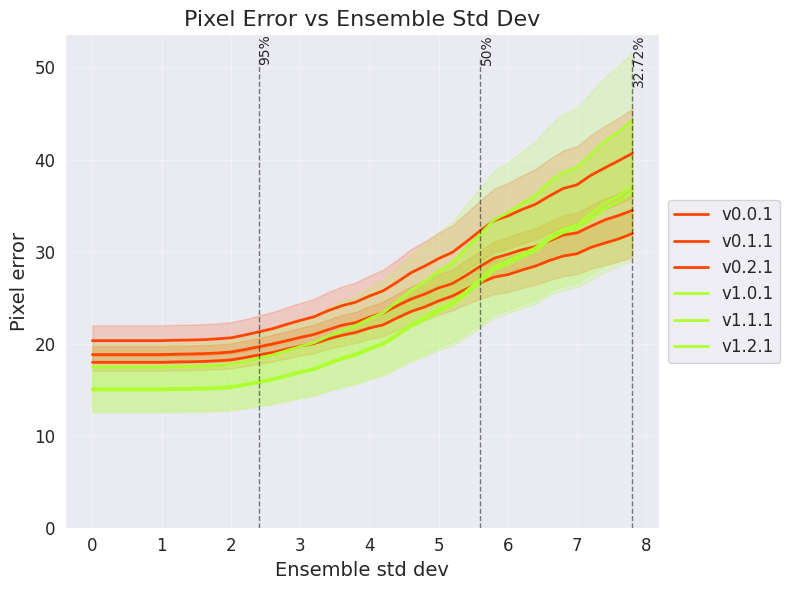

In [107]:
# Define the models we want to plot
models_to_plot = list(data_to_plot.keys())

# Define the color mapping
color_mapping = {
    'v0': '#FF4500',  # Orange Red
    'v0.0': '#FF4500',
    'v0.1': '#FF4500',
    'v0.2': '#FF4500',
    'v0.0.0': '#FF4500',
    'v0.1.0': '#FF4500',
    'v0.2.0': '#FF4500',
    'v0.0.1': '#FF4500',
    'v0.1.1': '#FF4500',
    'v0.2.1': '#FF4500',
    'v0e': '#DC143C',  # Crimson
    'v1': '#ADFF2F',  # Green Yellow
    'v1.0': '#ADFF2F',
    'v1.1': '#ADFF2F',
    'v1.2': '#ADFF2F',
    'v1.0.0': '#ADFF2F',
    'v1.1.0': '#ADFF2F',
    'v1.2.0': '#ADFF2F',
    'v1.0.1': '#ADFF2F',
    'v1.1.1': '#ADFF2F',
    'v1.2.1': '#ADFF2F',
    'v1e': '#32CD32',  # Lime Green
    'v2': '#1E90FF',  # Dodger Blue
    'v2.0': '#1E90FF',
    'v2.1': '#1E90FF',
    'v2.2': '#1E90FF',
    'v2e': '#8A2BE2',  # Blue Violet
    'v2s': '#000000',  # Black
    'v24k.0': '#1E90FF',
    'v24k.1': '#1E90FF',
    'v24k.2': '#1E90FF',
    'v24k': '#1E90FF',
    'v25k.0': '#000000',
    'v25k.1': '#000000',
    'v25k.2': '#000000',
    'v25k': '#000000',
    'v25ke': '#FF4500',  # Orange Red
    'v3': '#00CED1',  # Dark Turquoise
    'v3.0': '#00CED1',
    'v3.1': '#00CED1',
    'v3.2': '#00CED1',
    'v3_5k_128.0': '#00CED1',
    'v35k.1': '#00CED1',
    'v35k.2': '#00CED1',
    'v3_5k_128': '#00CED1',
    'v35ke': '#32CD32',  # Lime Green
    'v3_1.5k_128': '#FF4500',  # Orange Red
    'v3_1.5k_256': '#8A2BE2',  # Blue Violet
    'v3_5k_256': '#32CD32',  # Lime Green
#     'eks': '#FF1493',             # Deep Pink
#     'network_rng2_in_context': '#FFD700',  # Gold
}

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for model in models_to_plot:
    data = df_line2[df_line2['model'] == model]
    sns.lineplot(x='ens-std', y='mean', data=data, label=model, 
                 color=color_mapping[model], ax=ax, errorbar='se', linewidth=2)

ax.set_title('Pixel Error vs Ensemble Std Dev', fontsize=16)
ax.set_ylabel('Pixel error', fontsize=14)
ax.set_xlabel('Ensemble std dev', fontsize=14)
ax.set_ylim(bottom=0)  # Ensure y-axis starts at 0
ax.tick_params(axis='both', which='major', labelsize=12)

# Customize legend
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# Plot annotations
percentiles = [95, 50, 5]

vals, prctiles = compute_percentiles(
    arr=n_points_dict[models_to_plot[1]],
    std_vals=std_vals,
    percentiles=percentiles,
)

for p, v in zip(prctiles, vals):
    ax.axvline(v, ymax=0.95, linestyle='--', linewidth=1, color='black', alpha=0.5)
    ax.text(v, ax.get_ylim()[1], f'{p}%', ha='left', va='top', fontsize=10, rotation=90)

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()
